# تقطيع الصورة باستخدام خوارزمية <span class="girk">Watersherd</span>:

2016-00-01 15:37:14 

## الهدف:

** في هذا الفصل**

* سنتعلم كيف نقطع الصورة بناء على التعليم باستخدام خوارزمية WaterSherd.

* سنرى التابع: **cv2.watershed**

## النظرية:


اي صورة رمادية يمكن عرضها كسطح طبوغرافي , حيث الشدات العالية تمثل القمم والشدات المنخفضة , تمثل المنخفضات .  وستبدأ بملئ كل منخفض منعزل بالماء , (قيمة صغرى محلية) وبلون مميز , وعند ارتقاع الماء بالاعتماد على المنحنيات المحيطة فان المياه ذات الالوان المختلفة ستبدأ بالاختلاط , ولتجنب هذا سنبني حواجز لمنع هذا , ونستمر ببناء الحواجز وسكب الماء حتى غمر كل القمم , وعندها فان الحواجز التي بنيتها بالنهاية ستشكل نتيجة التقطيع. وهذه هي الفلسفة العامة خلف الwatershed.

ولكن هذا قد يعطينا تقطيعاً مفرطاً بسبب الضجيج في الصورة . ولذلك قامت OpenCV بتقديم تحوير لها يسمح للمستخدم ان يحدد اي المناطق يمكن دمجها وايها لا. وبذلك يكون هذا تقطيعاً تفاعلياً . حيث نحدد المناطق التي تشكل الجسم , الامامية , ومن ثم المناطق التي تشكل الخلفية , الاكيدة , اما القسم الثالث , الذي لم نتأكد منه فنحدده بالقيمة 0 , ومن ثم نطبق الخوارزمية حيث نرى التحديدات تتحدث , وحدود الجسم اخيراً ستحدد بالقيمة -1.

## البرنامج:
سنرى ادناه مثالاً , لاستخدام تحويل المسافة مع خوارزمية ال Watershed لتقطيع الاجسام المتلامسة .

فليكن لدينا الصورة ادناه للنقود التي تمس بعضها , وحتى بعد التعتيب ستبقى كذلك.
سنبدأ بايجاد التحديد التقريبي للنقود ولهذا سنستخدم التعتيب لاوتوس.



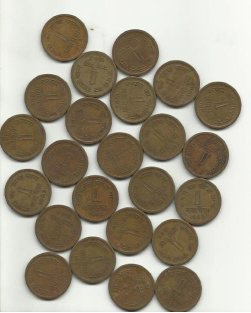

In [1]:
from IPython.display import Image
Image('coins.jpg')

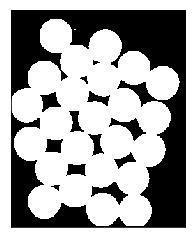

In [2]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

%matplotlib inline

img = cv2.imread('coins.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
ret, thresh = cv2.threshold(gray,0,255,
                            cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

plt.imshow(thresh , cmap='gray')
plt.xticks([])
plt.yticks([])
plt.show()

والان سنحتاج ان نزيل اي ضجيج بلون ابيض بالصورة . ولذلك نقوم بالفتح المورفولوجي , ولازالة الثقوب السوداء نقوم بالاغلاق , ولذلك نحن نعلم ان المناطق القريبة من مراكز القطع هي امامية حقاً , والمراكز البعيدة هي الخلفية ولكن يبقى مناطق الحدود هي التي لم نتحقق منها.


ولذلك نحتاج لاشتقاق المساحة التي تأكدنا انها القطع ,وذلك عبر ال Erosion  والباقي حتماً هو القطع . وهذا قد بعمل جيداً في حال كانت القطع لا تمس بعضها , اما وهي تمس بعضها , فسنحتاج لعمل تحويل المسافة ثم تطبيق عتبة مناسبة , وبعدها علينا ايجاد المنطقة الخلفية الاكيدة , ولذلك نقوم ب dilation  للنتيجة  , وهذا يزيد حدود الجسم للخلفية , وبهذا نتأكد اياً تكن المنطقة بالخلفية نتأكد انها خلفية حقيقية بما أن منطقة الحدود مزالة 
بين الجسم والخلفية  كما الصور التالية

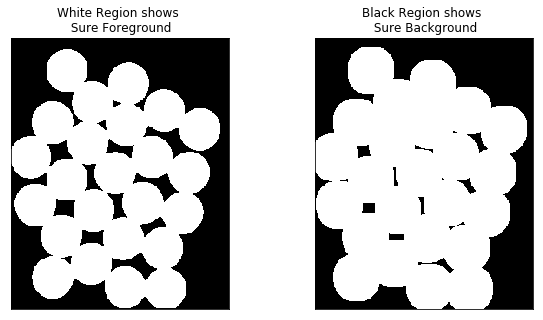

In [3]:
# noise Removal

kernel = np.ones((3,3),np.uint8)
opening = cv2.morphologyEx(thresh,
                           cv2.MORPH_OPEN,kernel,
                           iterations = 2)

# sure background area
sure_bg = cv2.dilate(opening,kernel,iterations=3)


plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(opening , cmap='gray')
plt.xticks([])
plt.yticks([])
plt.title('White Region shows \n Sure Foreground')

plt.subplot(122)
plt.imshow(sure_bg , cmap='gray')
plt.xticks([])
plt.yticks([])
plt.title('Black Region shows \n Sure Background')

plt.show()

المناطق المتبقية هي تلك التي لا نعرف حقاً هل هي جسم ام خلفية , وخوارزمية Watershed يجب ان توجدها . وهي المناطق التي تلتقي بها القطع والخلفية او حتى القطع مع بعضها , وندعوها بالحدود كما يمكن اكتسابها من طرح الخلفية الاكيدة من الامامية الاكيدة

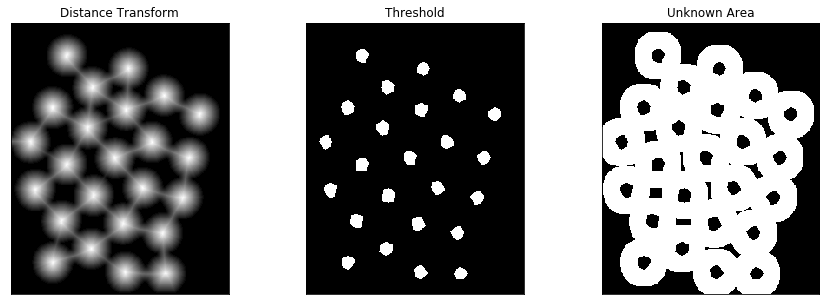

In [4]:
# Finding sure foreground area
dist_transform = cv2.distanceTransform(opening,
                                       cv2.cv.CV_DIST_L2,5)
ret, sure_fg = cv2.threshold(dist_transform,
                             0.7*dist_transform.max(),255,0)

# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg,sure_fg)


plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(dist_transform , cmap='gray')
plt.xticks([])
plt.yticks([])
plt.title('Distance Transform')

plt.subplot(132)
plt.imshow(sure_fg , cmap='gray')
plt.xticks([])
plt.yticks([])
plt.title('Threshold')

plt.subplot(133)
plt.imshow(unknown , cmap='gray')
plt.xticks([])
plt.yticks([])
plt.title('Unknown Area')

plt.show()

والان بعد معرفة مناطق القطع الاكيدة , سننشأ معلماً Marker بنفس قياس الصورة الاصلية ولكن بنمط متفيرات int32 ونحدد المناطق داخله , ونحدد المناطق داخله . والمناطق الامامية نحددها باي عدد صحيح موجب , ولكن بارقام مختلفة لكل جسم , والمناطق التي لا نعلمها بشكل اكيد نتركها صفراً ,  ولهذا سنستخدم  **cv2.connectedComponents ** ونحدد الخلفية لهذه الصورة ب 0 , والاجسام الاخرى باعداد صحيحة ابتداءً من 1 .

ولكن اذا كانت قيمة الخلفية 0 فستعتبرها الخوارزمية غير معلومة , بدلاً عن ذلك سنحدد المناطق غير المعلومة ب0 كالتالي:

In [ ]:
# Marker labelling
# it didn't work on opencv2.4.9 , so..
markers,ret = cv2.connectedComponents(sure_fg)

# Add one to all labels so that sure background is not 0, but 1
markers = sure_fg+1

# Now, mark the region of unknown with zero
markers[unknown==255] = 0

plt.imshow(markers )
plt.xticks([])
plt.yticks([])
plt.show()

التالي يمثل النتيجة ب Jet . الازرق الغامق يظهر المناطق المجهولة ,  القطع الاكيدة تلون بالوان مختلفة ,  المناطق المتبقية والتي هي خلفيات اكيدة  تظهر بلون ازرق افتح بالنسبة للمناطق المجهولة 


والان القناع جاهز . وحان الوقت للخطوة الاخيرة , وهي تطبيق الwatershed . وعندها صورة القناع ستتعدل . والمنطقة الحدية ستأخذ القيمة -1


In [ ]:
cv2.watershed(img,markers) 
# you got to assign it in v3.0
img[markers == -1] = [255,0,0]

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(markers )

plt.xticks([])
plt.yticks([])
plt.title('Marker Image  \n After segmntation')

plt.subplot(122)
plt.imshow(img )
plt.xticks([])
plt.yticks([])
plt.title('Result')

plt.show()

<img  src="New Picture.jpg"/>

لاحظ النتيجة وان بعض القطع ذات تقطيع مثالي واخرى ليست كذلك ..

## مراجع اخرى:


1. صفحة CMM المتعلقة بتحويل Watershed.


## تمارين :
1. تحتوي امثلة OpenCV على مثال تفاعلي لخوارزمية Watershed , شغلها , استمتع بها , ومن ثم تعلمها..

In [ ]:
#!/usr/bin/env python

'''
Watershed segmentation
=========

This program demonstrates the watershed segmentation algorithm
in OpenCV: watershed().

Usage
-----
watershed.py [image filename]

Keys
----
  1-7   - switch marker color
  SPACE - update segmentation
  r     - reset
  a     - toggle autoupdate
  ESC   - exit

'''




import numpy as np
import cv2
from common import Sketcher

class App:
    def __init__(self, fn):
        self.img = cv2.imread(fn)
        h, w = self.img.shape[:2]
        self.markers = np.zeros((h, w), np.int32)
        self.markers_vis = self.img.copy()
        self.cur_marker = 1
        self.colors = np.int32( list(np.ndindex(2, 2, 2)) ) * 255

        self.auto_update = True
        self.sketch = Sketcher('img', [self.markers_vis, self.markers], self.get_colors)

    def get_colors(self):
        return map(int, self.colors[self.cur_marker]), self.cur_marker

    def watershed(self):
        m = self.markers.copy()
        cv2.watershed(self.img, m)
        overlay = self.colors[np.maximum(m, 0)]
        vis = cv2.addWeighted(self.img, 0.5, overlay, 0.5, 0.0, dtype=cv2.CV_8UC3)
        cv2.imshow('watershed', vis)

    def run(self):
        while True:
            ch = 0xFF & cv2.waitKey(50)
            if ch == 27:
                break
            if ch >= ord('1') and ch <= ord('7'):
                self.cur_marker = ch - ord('0')
                print 'marker: ', self.cur_marker
            if ch == ord(' ') or (self.sketch.dirty and self.auto_update):
                self.watershed()
                self.sketch.dirty = False
            if ch in [ord('a'), ord('A')]:
                self.auto_update = not self.auto_update
                print 'auto_update if', ['off', 'on'][self.auto_update]
            if ch in [ord('r'), ord('R')]:
                self.markers[:] = 0
                self.markers_vis[:] = self.img
                self.sketch.show()
        cv2.destroyAllWindows()


if __name__ == '__main__':
    import sys
    try: fn = sys.argv[1]
    except: fn = '../cpp/fruits.jpg'
    print __doc__
    App(fn).run()


السابق هو البرنامج المذكور , لاحظ انه تطبيق تفاعلي.

In [22]:
%load_ext version_information
%version_information numpy, scipy, matplotlib

Software versions
Python 2.7.9 32bit [MSC v.1500 32 bit (Intel)]
IPython 4.0.1
OS Windows 7 6.1.7601 SP1
numpy 1.9.2
scipy 0.16.0
matplotlib 1.4.3
Sat Jan 02 20:36:51 2016 سوريا - التوقيت الرسمي